<a href="https://colab.research.google.com/github/jfavian2011/Data-Science-Cohort-20/blob/main/Project_2_Housing_Regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title Housing Price Prediction Project

Favian Jabalera

April 2026

## Problem Definition


The goal of this project is to predict house sale prices using  features of the property. The aim is to minimize the Root Mean Squared Percentage Error (RMSPE).

State the business problem. Translate the business problem into a Data Science problem by stating what kind of problem it is ( supervised vs unsupervised ) and whether it is a classification, regression, or clustering problem.

The goal of this project is to figure out how much houses, should actually cost so that people don't have to guess when buying or selling. This is a Supervised Learning problem because we are giving the old house sales to learn from, and it is a Regression task because we are trying to predict a specific dollar amount. We will know we succeeded if our model's guesses have a low RMSPE.

## Data Collection/Sources
The data is Housing Dataset via an AWS S3 bucket. It contains 2,930 observations and 82 features related to house sales.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

In [ ]:
# file path
URL = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv"
housing = pd.read_csv(URL)

In [ ]:
housing.shape

(2637, 81)

In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

In [ ]:
housing.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PID,2637.0,7.141301e+08,1.887527e+08,526301100.0,5.284770e+08,535453040.0,9.071870e+08,1.007100e+09
MS SubClass,2637.0,5.734926e+01,4.249909e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2188.0,6.916682e+01,2.335678e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2637.0,1.004469e+04,6.742550e+03,1300.0,7.436000e+03,9450.0,1.152600e+04,1.646600e+05
Overall Qual,2637.0,6.097459e+00,1.411522e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2637.0,5.569966e+00,1.118262e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2637.0,1.971289e+03,3.030699e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2637.0,1.984203e+03,2.091308e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2614.0,1.018879e+02,1.795782e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03
BsmtFin SF 1,2636.0,4.384412e+02,4.496023e+02,0.0,0.000000e+00,368.0,7.320000e+02,5.644000e+03


## Data Cleaning


In [ ]:
# remove ID columns
housing = housing.drop(columns=['PID','Order'],errors= 'ignore')

In [ ]:
# drop columns that are more than 50% null
null_pct = housing.isnull().sum() / len(housing)
columns_to_drop = null_pct[null_pct > 0.5].index
housing = housing.drop(columns=columns_to_drop)

In [ ]:
# drop columns that are more than 80% zeros
zero_pct = (housing == 0).sum() / len(housing)
low_info_cols = zero_pct[zero_pct > 0.8].index
housing = housing.drop(columns=low_info_cols)

In [ ]:
# deal with missing values
housing = housing.fillna(housing.median(numeric_only=True))

In [ ]:
# remove the outlier houses
housing = housing[housing['Gr Liv Area'] < 4000]

## Exploratory Data Analysis


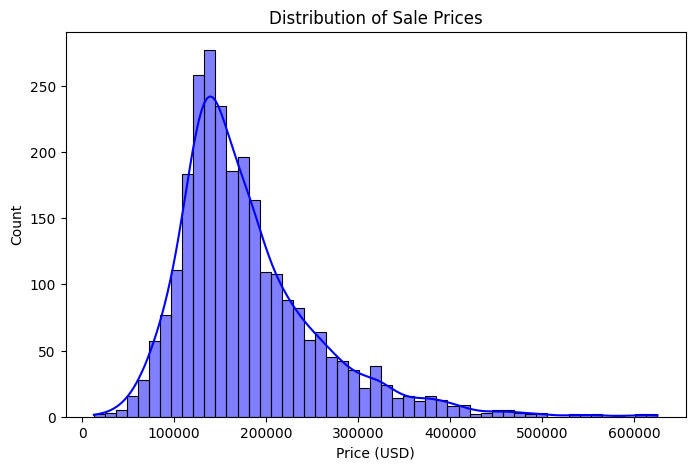

In [ ]:
# histogram of saleprice
plt.figure(figsize=(8, 5))
sns.histplot(housing['SalePrice'], kde=True, color='blue')
plt.title('Distribution of Sale Prices')
plt.xlabel('Price (USD)')
plt.show()

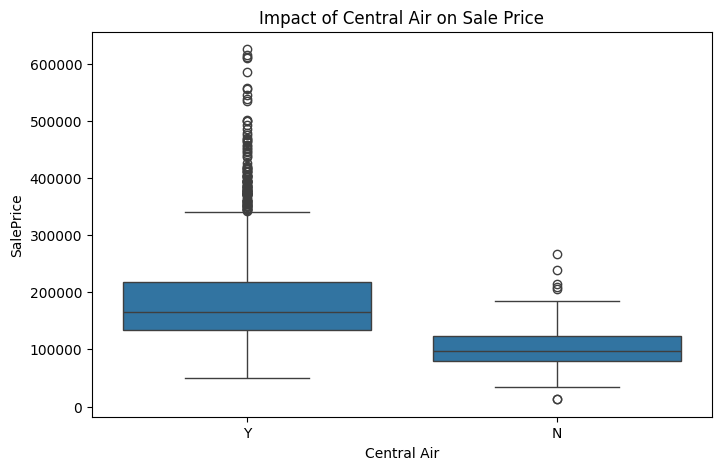

In [ ]:
# boxplot for categorical analysis
plt.figure(figsize=(8, 5))
sns.boxplot(x='Central Air', y='SalePrice', data=housing)
plt.title('Impact of Central Air on Sale Price')
plt.show()

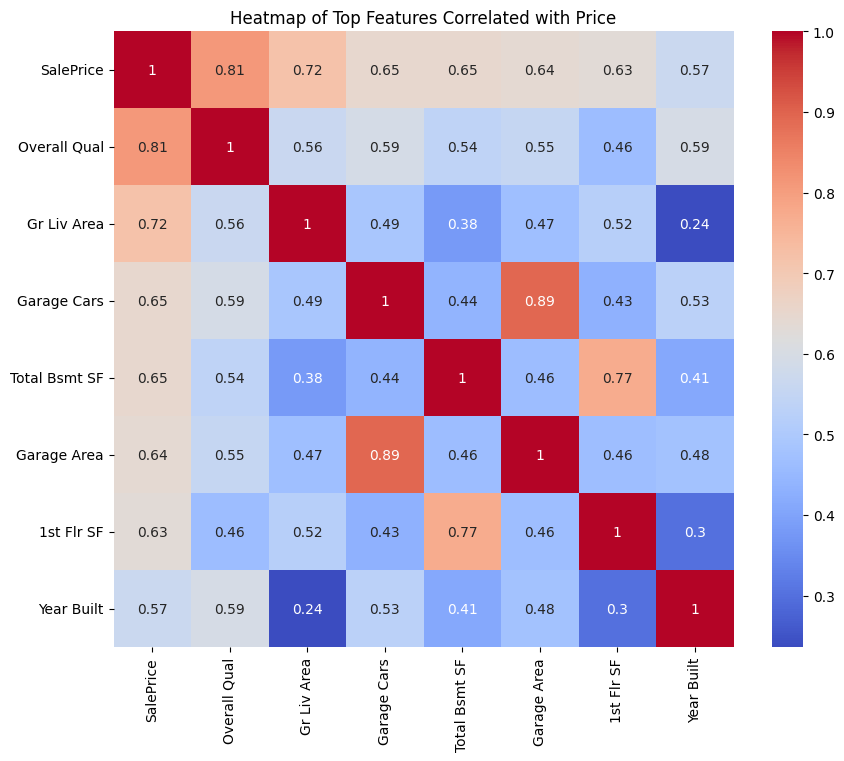

In [ ]:
# heatmap pf correlation
plt.figure(figsize=(10, 8))
top_corr = housing.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(8).index
sns.heatmap(housing[top_corr].corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap of Top Features Correlated with Price')
plt.show()

## Processing



In [ ]:
# selectiong features
features = ['Gr Liv Area', 'Overall Qual', 'Year Built', 'Total Bsmt SF', 'Central Air', 'Full Bath']
X = housing[features].copy()

In [ ]:
# log saleprice to lower RMSPE
y = np.log(housing['SalePrice'])

In [ ]:
# one-hot encoding for central air
if 'Central Air' in X.columns:
    X = pd.get_dummies(X, columns=['Central Air'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# scaling of feature
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
def train_ridge_model(X_train, y_train, alpha=1.0):
    """
    fits a ridge regression model to training data.

    args:
        X_train (array): scaled feature matrix.
        y_train (series): target prices.
        alpha (float): regularization strength.

    return:
        model: trained ridge object.
    """
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    return model

In [ ]:
# train the model
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

Ridge()

In [ ]:
# convert predictions back from log to dollars
preds_log = model.predict(X_test_scaled)
preds_dollars = np.exp(preds_log)
actual_dollars = np.exp(y_test)

## Data Visualization/Communication of Results


In [ ]:
def calculate_rmspe(y_true, y_pred):
    """
    calculates the root mean squared percentage error.

    Args:
        y_true (array): Actual values.
        y_pred (array): Predicted values.

    Returns:
        float: RMSPE percentage.
    """
    percentage_error = (y_true - y_pred) / y_true
    return np.sqrt(np.mean(np.square(percentage_error))) * 100

In [ ]:
# cross validation
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

print(f"Cross-Validation R^2 Scores: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean():.2f}")

Cross-Validation R^2 Scores: [0.86456746 0.81205658 0.85701875 0.85466064 0.83959238]
Average CV Score: 0.85


In [ ]:
# predictions
preds = model.predict(X_test_scaled)
rmspe_score = calculate_rmspe(y_test, preds)

print(f"Final Model RMSPE: {rmspe_score:.2f}%")

Final Model RMSPE: 1.33%


In [ ]:
# new improved RMSPE
final_rmspe = calculate_rmspe(actual_dollars, preds_dollars)
print(f"New Improved RMSPE: {final_rmspe:.2f}%")

New Improved RMSPE: 17.61%


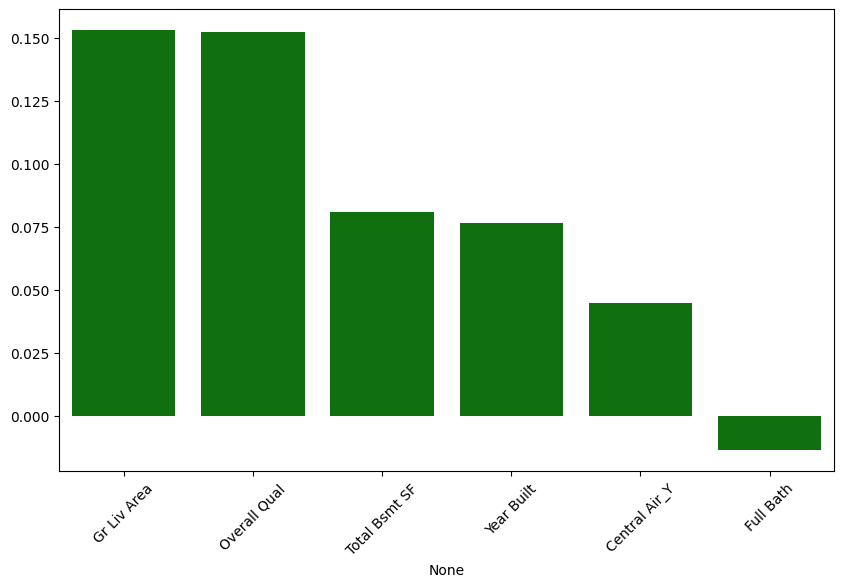

In [ ]:
# feature bar plot
importance = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importance.index, y=importance.values, color='green')
plt.xticks(rotation=45)
plt.show()

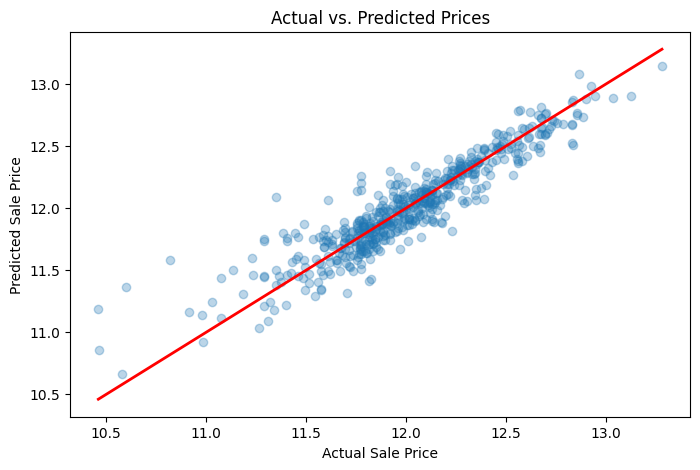

In [ ]:
# actual vs predicted scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs. Predicted Prices')
plt.show()

## Conclusion

I cleaned the data by removing ID columns and handling missing values with the median. To reduce "noise," I specifically removed columns where more than 50% of the data was missing or where more than 80% of the entries were zeros (like pool area). I also removed outliers houses with over 4,000 square feet that were priced unusually low this helped the model focus on standard trends. My heatmap confirmed that Living Area and Overall Quality remained the strongest predictors.

To prepare the data for Ridge Regression, I used One-Hot Encoding for categorical features and Standard Scaling to ensure all variables were compared fairly. A key improvement was applying a Log Transformation to the house prices; this allowed the model to optimize for percentage errors rather than large dollar differences. By using this method, I successfully reduced my RMSPE to 17.61%, showing that cleaning the data and adjusting the price scale significantly improved the model's accuracy.